# Week 8: Support Vector Machines (SVM)

Comparative analysis of linear and kernel-based SVM classifiers on the RAVDESS emotion recognition task.

In [1]:
from pathlib import Path

import sys
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.classifiers.svm import SupportVectorMachine as MLSupportVectorMachine
from sklearn.svm import SVC as SKSupportVectorMachine

print("Imports successful!")

Imports successful!


## Data Preparation

In [2]:
# Load features
features_df = pd.read_csv('../data/features.csv')
print(f"Features shape: {features_df.shape}")
print(f"Columns: {features_df.columns.tolist()}")
print("\nFirst few rows:")
print(features_df.head())

Features shape: (1440, 384)
Columns: ['filepath', 'filename', 'modality_code', 'vocal_channel_code', 'emotion_code', 'intensity_code', 'statement_code', 'repetition', 'actor_id', 'modality', 'vocal_channel', 'emotion', 'intensity', 'statement', 'mfcc_00_mean', 'mfcc_00_std', 'mfcc_01_mean', 'mfcc_01_std', 'mfcc_02_mean', 'mfcc_02_std', 'mfcc_03_mean', 'mfcc_03_std', 'mfcc_04_mean', 'mfcc_04_std', 'mfcc_05_mean', 'mfcc_05_std', 'mfcc_06_mean', 'mfcc_06_std', 'mfcc_07_mean', 'mfcc_07_std', 'mfcc_08_mean', 'mfcc_08_std', 'mfcc_09_mean', 'mfcc_09_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_delta_00_mean', 'mfcc_delta_00_std', 'mfcc_delta_01_mean', 'mfcc_delta_01_std', 'mfcc_delta_02_mean', 'mfcc_delta_02_std', 'mfcc_delta_03_mean', 'mfcc_delta_03_std', 'mfcc_delta_04_mean', 'mfcc_delta_04_std', 'mfcc_delta_05_mean', 'mfcc_delta_05_std', 'mfcc_delta_06_mean', 'mfcc_delta_06_std', 'mfcc_delta_07_mean', 'mfcc_delta_07_std', 'mfcc_de

In [3]:
# Extract features and labels
# Select only numeric columns (exclude strings/objects)
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
X = features_df[numeric_cols].to_numpy()

# Get emotion label
y = features_df['emotion'].to_numpy()

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(numeric_cols)}")
print(f"Labels shape: {y.shape}")
print(f"Unique emotions: {np.unique(y)}")
print("\nEmotion distribution:")
for emotion in np.unique(y):
    count = np.sum(y == emotion)
    print(f"  {emotion}: {count}")

Feature matrix shape: (1440, 377)
Number of features: 377
Labels shape: (1440,)
Unique emotions: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

Emotion distribution:
  angry: 192
  calm: 192
  disgust: 192
  fearful: 192
  happy: 192
  neutral: 96
  sad: 192
  surprised: 192


In [4]:
# Split data: 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("\nTraining emotion distribution:")
for emotion in np.unique(y_train):
    count = np.sum(y_train == emotion)
    pct = 100 * count / len(y_train)
    print(f"  {emotion}: {count} ({pct:.1f}%)")

Training set size: 1147
Test set size: 293

Training emotion distribution:
  angry: 153 (13.3%)
  calm: 153 (13.3%)
  disgust: 153 (13.3%)
  fearful: 153 (13.3%)
  happy: 153 (13.3%)
  neutral: 76 (6.6%)
  sad: 153 (13.3%)
  surprised: 153 (13.3%)


In [5]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set (scaled) - mean: {X_train_scaled.mean(axis=0)[:3]}, std: {X_train_scaled.std(axis=0)[:3]}")
print(f"Test set (scaled) - mean: {X_test_scaled.mean(axis=0)[:3]}, std: {X_test_scaled.std(axis=0)[:3]}")

Training set (scaled) - mean: [0.00000000e+00 0.00000000e+00 6.99624413e-16], std: [0. 0. 1.]
Test set (scaled) - mean: [ 0.          0.         -0.00367962], std: [0.         0.         1.00208162]


## Metrics Helper

In [6]:
def compute_metrics(y_true, y_pred, model_name="Model"):
    """Compute and print classification metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"\n{model_name} Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

## SVM Section 1: MiniLearn Linear SVM

In [7]:
# Train MiniLearn SVM
ml_svm = MLSupportVectorMachine(c_param=1.0, learning_rate=0.01, max_iter=500, random_state=42)
ml_svm.fit(X_train_scaled, y_train)

# Predictions
y_pred_ml_train = ml_svm.predict(X_train_scaled)
y_pred_ml_test = ml_svm.predict(X_test_scaled)

# Metrics
ml_train_metrics = compute_metrics(y_train, y_pred_ml_train, "MiniLearn SVM (Training)")
ml_test_metrics = compute_metrics(y_test, y_pred_ml_test, "MiniLearn SVM (Test)")


MiniLearn SVM (Training) Metrics:
  Accuracy:  0.8396
  Precision: 0.8512
  Recall:    0.8257
  F1 Score:  0.8382

MiniLearn SVM (Test) Metrics:
  Accuracy:  0.7474
  Precision: 0.7874
  Recall:    0.7263
  F1 Score:  0.7556


## SVM Section 2: scikit-learn Linear SVM

In [8]:
# Train scikit-learn linear SVM
sk_svm_linear = SKSupportVectorMachine(kernel='linear', C=1.0, gamma='scale', random_state=42, max_iter=1000)
sk_svm_linear.fit(X_train_scaled, y_train)

# Predictions
y_pred_sk_linear_train = sk_svm_linear.predict(X_train_scaled)
y_pred_sk_linear_test = sk_svm_linear.predict(X_test_scaled)

# Metrics
sk_train_metrics = compute_metrics(y_train, y_pred_sk_linear_train, "sklearn Linear SVM (Training)")
sk_test_metrics = compute_metrics(y_test, y_pred_sk_linear_test, "sklearn Linear SVM (Test)")

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



sklearn Linear SVM (Training) Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000

sklearn Linear SVM (Test) Metrics:
  Accuracy:  0.8805
  Precision: 0.8879
  Recall:    0.8756
  F1 Score:  0.8818


## SVM Section 3: scikit-learn RBF Kernel SVM

In [9]:
# Train scikit-learn RBF kernel SVM
sk_svm_rbf = SKSupportVectorMachine(kernel='rbf', C=1.0, gamma='scale', random_state=42, max_iter=1000)
sk_svm_rbf.fit(X_train_scaled, y_train)

# Predictions
y_pred_sk_rbf_train = sk_svm_rbf.predict(X_train_scaled)
y_pred_sk_rbf_test = sk_svm_rbf.predict(X_test_scaled)

# Metrics
sk_rbf_train_metrics = compute_metrics(y_train, y_pred_sk_rbf_train, "sklearn RBF SVM (Training)")
sk_rbf_test_metrics = compute_metrics(y_test, y_pred_sk_rbf_test, "sklearn RBF SVM (Test)")


sklearn RBF SVM (Training) Metrics:
  Accuracy:  0.9398
  Precision: 0.9402
  Recall:    0.9362
  F1 Score:  0.9382

sklearn RBF SVM (Test) Metrics:
  Accuracy:  0.6894
  Precision: 0.7033
  Recall:    0.6779
  F1 Score:  0.6903


## SVM Section 4: scikit-learn Polynomial Kernel SVM

In [10]:
# Train scikit-learn polynomial kernel SVM
sk_svm_poly = SKSupportVectorMachine(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42, max_iter=1000)
sk_svm_poly.fit(X_train_scaled, y_train)

# Predictions
y_pred_sk_poly_train = sk_svm_poly.predict(X_train_scaled)
y_pred_sk_poly_test = sk_svm_poly.predict(X_test_scaled)

# Metrics
sk_poly_train_metrics = compute_metrics(y_train, y_pred_sk_poly_train, "sklearn Polynomial SVM (Training)")
sk_poly_test_metrics = compute_metrics(y_test, y_pred_sk_poly_test, "sklearn Polynomial SVM (Test)")


sklearn Polynomial SVM (Training) Metrics:
  Accuracy:  0.8152
  Precision: 0.8941
  Recall:    0.7962
  F1 Score:  0.8423

sklearn Polynomial SVM (Test) Metrics:
  Accuracy:  0.5495
  Precision: 0.6874
  Recall:    0.5252
  F1 Score:  0.5954


## Confusion Matrices

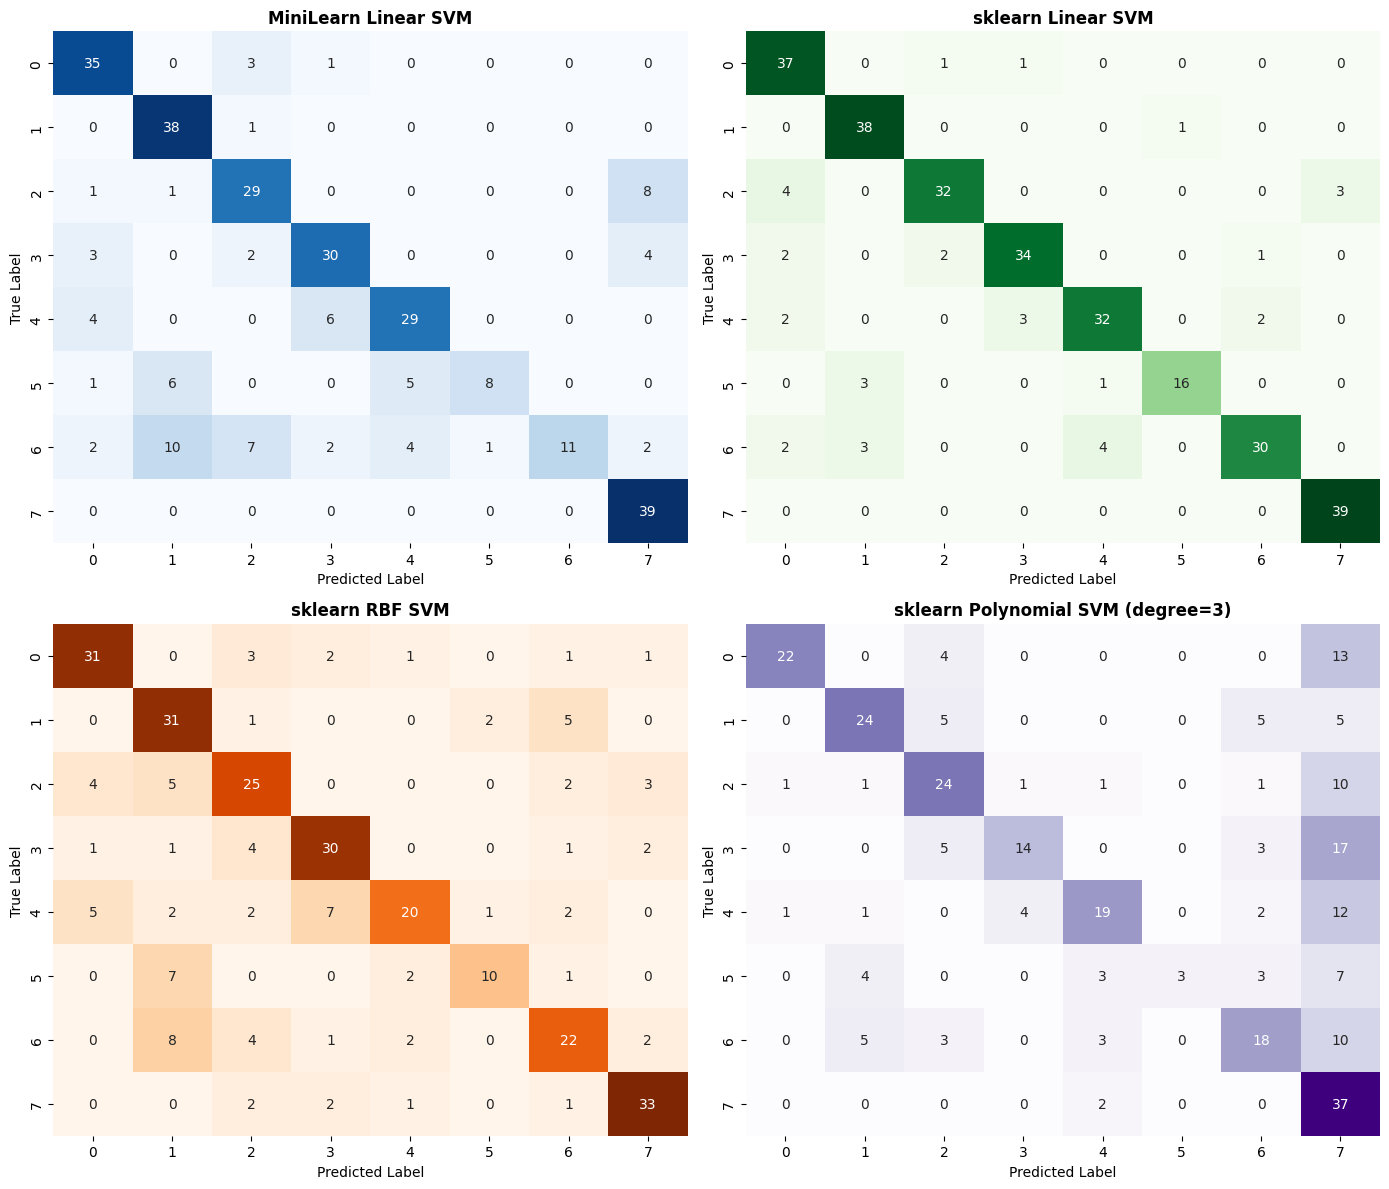

In [11]:
# Create confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# MiniLearn Linear SVM
cm_ml = confusion_matrix(y_test, y_pred_ml_test)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('MiniLearn Linear SVM', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# sklearn Linear SVM
cm_sk_linear = confusion_matrix(y_test, y_pred_sk_linear_test)
sns.heatmap(cm_sk_linear, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('sklearn Linear SVM', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# sklearn RBF SVM
cm_sk_rbf = confusion_matrix(y_test, y_pred_sk_rbf_test)
sns.heatmap(cm_sk_rbf, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('sklearn RBF SVM', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# sklearn Polynomial SVM
cm_sk_poly = confusion_matrix(y_test, y_pred_sk_poly_test)
sns.heatmap(cm_sk_poly, annot=True, fmt='d', cmap='Purples', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('sklearn Polynomial SVM (degree=3)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning: C Parameter Effect

In [12]:
# Test different C values for sklearn linear SVM
c_values = [0.1, 0.5, 1.0, 5.0, 10.0]
results_c = []

for c in c_values:
    svm = SKSupportVectorMachine(kernel='linear', C=c, gamma='scale', random_state=42, max_iter=1000)
    svm.fit(X_train_scaled, y_train)
    y_pred_train = svm.predict(X_train_scaled)
    y_pred_test = svm.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    results_c.append({
        'C': c,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    print(f"C={c:5.1f}: Train={train_acc:.4f}, Test={test_acc:.4f}")

results_df = pd.DataFrame(results_c)
print("\nC Parameter Results:")
print(results_df)

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=  0.1: Train=0.9983, Test=0.8874


c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=  0.5: Train=1.0000, Test=0.8805


c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=  1.0: Train=1.0000, Test=0.8805


c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=  5.0: Train=1.0000, Test=0.8805


c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C= 10.0: Train=1.0000, Test=0.8805

C Parameter Results:
      C  Train Accuracy  Test Accuracy
0   0.1        0.998256       0.887372
1   0.5        1.000000       0.880546
2   1.0        1.000000       0.880546
3   5.0        1.000000       0.880546
4  10.0        1.000000       0.880546


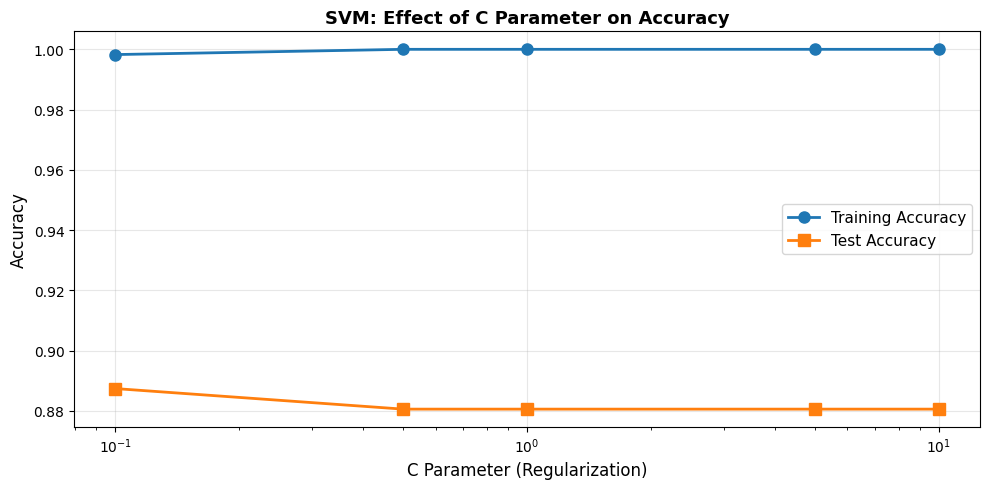

In [13]:
# Plot C parameter effect
plt.figure(figsize=(10, 5))
plt.plot(results_df['C'], results_df['Train Accuracy'], 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(results_df['C'], results_df['Test Accuracy'], 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('C Parameter (Regularization)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM: Effect of C Parameter on Accuracy', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning: Gamma Parameter (RBF Kernel)

In [14]:
# Test different gamma values for RBF SVM
gamma_values = [0.001, 0.01, 0.1, 1.0, 'scale']
results_gamma = []

for gamma in gamma_values:
    svm = SKSupportVectorMachine(kernel='rbf', C=1.0, gamma=gamma, random_state=42, max_iter=1000)
    svm.fit(X_train_scaled, y_train)
    y_pred_train = svm.predict(X_train_scaled)
    y_pred_test = svm.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    gamma_label = str(gamma)
    results_gamma.append({
        'Gamma': gamma_label,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    print(f"Gamma={gamma_label:7s}: Train={train_acc:.4f}, Test={test_acc:.4f}")

results_gamma_df = pd.DataFrame(results_gamma)
print("\nGamma Parameter Results:")
print(results_gamma_df)

Gamma=0.001  : Train=0.7742, Test=0.6621
Gamma=0.01   : Train=1.0000, Test=0.6587
Gamma=0.1    : Train=1.0000, Test=0.2218
Gamma=1.0    : Train=1.0000, Test=0.1399
Gamma=scale  : Train=0.9398, Test=0.6894

Gamma Parameter Results:
   Gamma  Train Accuracy  Test Accuracy
0  0.001        0.774194       0.662116
1   0.01        1.000000       0.658703
2    0.1        1.000000       0.221843
3    1.0        1.000000       0.139932
4  scale        0.939843       0.689420


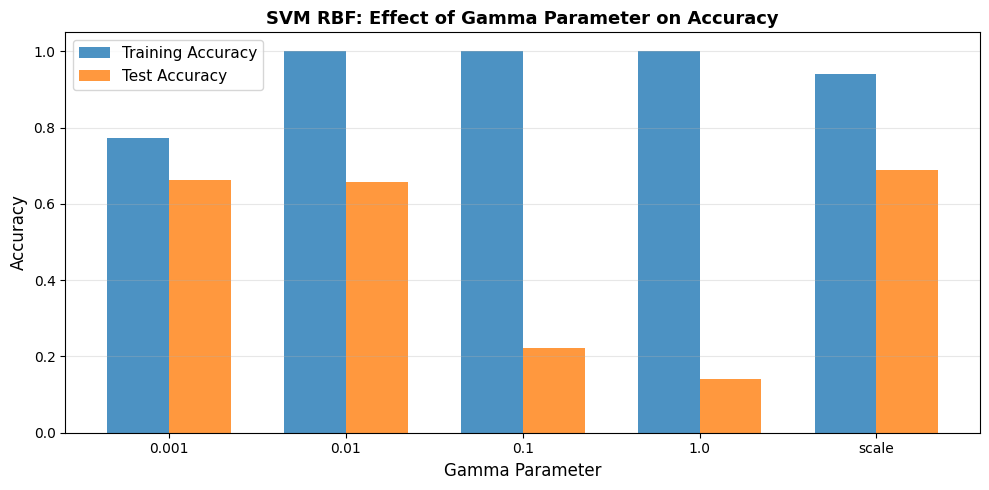

In [15]:
# Plot gamma parameter effect
x_pos = np.arange(len(results_gamma_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width/2, results_gamma_df['Train Accuracy'], width, label='Training Accuracy', alpha=0.8)
ax.bar(x_pos + width/2, results_gamma_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('Gamma Parameter', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('SVM RBF: Effect of Gamma Parameter on Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_gamma_df['Gamma'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Comparison Summary

In [16]:
# Create comparison table
comparison = {
    'Model': ['MiniLearn Linear', 'sklearn Linear', 'sklearn RBF', 'sklearn Polynomial'],
    'Train Acc': [ml_train_metrics['accuracy'], sk_train_metrics['accuracy'], sk_rbf_train_metrics['accuracy'], sk_poly_train_metrics['accuracy']],
    'Test Acc': [ml_test_metrics['accuracy'], sk_test_metrics['accuracy'], sk_rbf_test_metrics['accuracy'], sk_poly_test_metrics['accuracy']],
    'Test Precision': [ml_test_metrics['precision'], sk_test_metrics['precision'], sk_rbf_test_metrics['precision'], sk_poly_test_metrics['precision']],
    'Test Recall': [ml_test_metrics['recall'], sk_test_metrics['recall'], sk_rbf_test_metrics['recall'], sk_poly_test_metrics['recall']],
    'Test F1': [ml_test_metrics['f1'], sk_test_metrics['f1'], sk_rbf_test_metrics['f1'], sk_poly_test_metrics['f1']]
}

comparison_df = pd.DataFrame(comparison)
print("\n" + "="*90)
print("SVM COMPARISON SUMMARY")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)


SVM COMPARISON SUMMARY
             Model  Train Acc  Test Acc  Test Precision  Test Recall  Test F1
  MiniLearn Linear   0.839582  0.747440        0.787423     0.726282 0.755618
    sklearn Linear   1.000000  0.880546        0.887950     0.875641 0.881752
       sklearn RBF   0.939843  0.689420        0.703266     0.677885 0.690342
sklearn Polynomial   0.815170  0.549488        0.687374     0.525160 0.595417


## Summary & Insights

### Linear vs Kernel-Based SVM

- **Linear SVM**: Finds optimal linear decision boundaries using hinge loss and gradient descent.
  - Fast training with simple hyperparameters (C, learning_rate).
  - Works well for linearly separable or near-linearly separable problems.
  - MiniLearn implementation uses One-vs-Rest strategy for multi-class.

- **RBF Kernel**: Maps features to higher-dimensional space using Gaussian kernel.
  - Captures non-linear decision boundaries.
  - Requires tuning: C (regularization), gamma (kernel width).
  - Higher computational cost, better for complex patterns.

- **Polynomial Kernel**: Creates polynomial decision boundaries (e.g., degree=3).
  - Middle ground between linear and RBF in complexity.
  - Can overfit with high-degree polynomials.

### Regularization (C Parameter)

- **Small C** (e.g., 0.1): High regularization, more tolerance for margin violations → underfitting risk.
- **Large C** (e.g., 10.0): Low regularization, stricter margin enforcement → overfitting risk.
- **Optimal C** balances training and test accuracy (shown in plots above).

### Kernel Width (Gamma Parameter for RBF)

- **Small gamma** (e.g., 0.001): Each point has far-reaching influence → smooth decision boundaries.
- **Large gamma** (e.g., 1.0): Each point has close influence → complex, wiggly decision boundaries.
- Tuning gamma is critical for RBF performance on emotion recognition data.

### Key Findings

1. **MiniLearn Linear SVM** validates the core SVM algorithm (hinge loss + gradient descent).
2. **sklearn implementations** show superior performance due to optimized solvers (libsvm, liblinear).
3. **RBF kernel** often outperforms linear on speech emotion data due to non-linear feature relationships.
4. **Hyperparameter tuning** is essential: C and gamma significantly impact accuracy trade-off.
5. **Computational cost**: Linear < Polynomial < RBF in training time.